<a href="https://colab.research.google.com/github/DSPL-B17/DSPL_hotelchainA/blob/main/Decision_Tree_Model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hotel Chain A – Decision Tree Model
**Project:** Hotel Booking Dynamics: Exploring Cancellations and No-Shows  
**Objective:** Predict booking cancellations using a Decision Tree classifier and evaluate model performance.

##Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, accuracy_score)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
train      = pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Processed/train_cleaned.csv')
validation = pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Processed/validation_cleaned.csv')
test       = pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Processed/test_cleaned.csv')

print('Train:', train.shape)
print('Validation:', validation.shape)
print('Test:', test.shape)

Train: (27499, 40)
Validation: (2749, 38)
Test: (4318, 36)


In [4]:
# Standardise all column names to lowercase
train.columns      = train.columns.str.strip().str.lower()
validation.columns = validation.columns.str.strip().str.lower()
test.columns       = test.columns.str.strip().str.lower()

# Standardise the target label values
for df in [train, validation]:
    df['reservation_status'] = (
        df['reservation_status']
        .str.lower().str.strip()
        .replace({'check out': 'checkout', 'check-out': 'checkout', 'check-in': 'checkout'})
    )

print("Train columns (first 20):", list(train.columns[:20]))
print("\nClass distribution - Train:")
print(train['reservation_status'].value_counts())
print("\nClass distribution - Validation:")
print(validation['reservation_status'].value_counts())

Train columns (first 20): ['gender', 'age', 'ethnicity', 'educational_level', 'income', 'country_region', 'hotel_type', 'expected_checkin', 'expected_checkout', 'booking_date', 'adults', 'children', 'babies', 'meal_type', 'visted_previously', 'previous_cancellations', 'deposit_type', 'booking_channel', 'required_car_parking', 'reservation_status']

Class distribution - Train:
reservation_status
checkout    21240
canceled     4134
no-show      2125
Name: count, dtype: int64

Class distribution - Validation:
reservation_status
checkout    1610
canceled     741
no-show      398
Name: count, dtype: int64


In [5]:
print("Train - Reservation Status Distribution:")
print(train['reservation_status'].value_counts())
print()
print("Validation - Reservation Status Distribution:")
print(validation['reservation_status'].value_counts())

Train - Reservation Status Distribution:
reservation_status
checkout    21240
canceled     4134
no-show      2125
Name: count, dtype: int64

Validation - Reservation Status Distribution:
reservation_status
checkout    1610
canceled     741
no-show      398
Name: count, dtype: int64


##Feature Engineering & Preprocessing

Select Features
We pick features that are available at booking time (no data leakage) and exclude ID columns and the raw status label.

In [6]:
features = [
    'age', 'adults', 'children', 'babies',
    'room_rate', 'discount_rate',
    'lead_time',          # lowercase — matches saved CSV
    'length_of_stay',     # lowercase — matches saved CSV
    'checkin_month', 'checkin_dayofweek', 'is_weekend_checkin',
    'total_guests', 'is_family', 'capacity_exceeded',
    'income_enc', 'education_enc',
    'hotel_type', 'booking_channel', 'deposit_type',
    'meal_type', 'use_promotion', 'required_car_parking',
    'visted_previously', 'previous_cancellations',
    'gender', 'country_region', 'ethnicity', 'guest_type', 'checkin_season'
]

# Keep only features that actually exist in the dataset
features = [f for f in features if f in train.columns]
target = 'reservation_status'

print("Features selected:", len(features))
print("Missing features (check spelling):",
      [f for f in features if f not in train.columns])
print(features)

Features selected: 29
Missing features (check spelling): []
['age', 'adults', 'children', 'babies', 'room_rate', 'discount_rate', 'lead_time', 'length_of_stay', 'checkin_month', 'checkin_dayofweek', 'is_weekend_checkin', 'total_guests', 'is_family', 'capacity_exceeded', 'income_enc', 'education_enc', 'hotel_type', 'booking_channel', 'deposit_type', 'meal_type', 'use_promotion', 'required_car_parking', 'visted_previously', 'previous_cancellations', 'gender', 'country_region', 'ethnicity', 'guest_type', 'checkin_season']


In [7]:
cat_cols = [f for f in [
    'hotel_type', 'booking_channel', 'deposit_type', 'meal_type',
    'use_promotion', 'required_car_parking', 'visted_previously',
    'previous_cancellations', 'gender', 'country_region',
    'ethnicity', 'guest_type', 'checkin_season'
] if f in features]

train_enc      = pd.get_dummies(train[features], columns=cat_cols)
validation_enc = pd.get_dummies(validation[features], columns=cat_cols)
test_enc       = pd.get_dummies(test[features], columns=cat_cols)

# Align columns
train_enc, validation_enc = train_enc.align(validation_enc, join='left', axis=1, fill_value=0)
train_enc, test_enc       = train_enc.align(test_enc,       join='left', axis=1, fill_value=0)

# Fill NaNs
train_enc      = train_enc.fillna(0)
validation_enc = validation_enc.fillna(0)
test_enc       = test_enc.fillna(0)

print("Features after encoding:", train_enc.shape[1])

Features after encoding: 51



## Prepare X and y Splits

In [8]:
X_train = train_enc
y_train = train[target]

X_val = validation_enc
y_val = validation[target]

X_test = test_enc

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("Classes:", sorted(y_train.unique()))

X_train: (27499, 51)
X_val:   (2749, 51)
X_test:  (4318, 51)
Classes: ['canceled', 'checkout', 'no-show']


Handling class imbalance using SMOTE

In [9]:
from imblearn.over_sampling import SMOTE

print("=== Before SMOTE ===")
print(y_train.value_counts())

# Check minimum class size and set k_neighbors safely
min_class_size = y_train.value_counts().min()
k = min(5, min_class_size - 1)  # avoid error when class is very small
print(f"\nUsing k_neighbors={k} (based on smallest class size: {min_class_size})")

smote = SMOTE(random_state=42, k_neighbors=k)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\n=== After SMOTE ===")
print(pd.Series(y_train_bal).value_counts())

=== Before SMOTE ===
reservation_status
checkout    21240
canceled     4134
no-show      2125
Name: count, dtype: int64

Using k_neighbors=5 (based on smallest class size: 2125)

=== After SMOTE ===
reservation_status
checkout    21240
canceled    21240
no-show     21240
Name: count, dtype: int64


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes_list = ['canceled', 'checkout', 'no-show']

# Computing weights from the ORIGINAL (pre-SMOTE) training labels
cw = compute_class_weight(class_weight='balanced',
                           classes=np.array(classes_list),
                           y=y_train)

class_weight_dict = dict(zip(classes_list, cw))
print("Computed class weights:", class_weight_dict)

# Manually boosting canceled and no-show further
class_weight_dict['canceled'] *= 1.0
class_weight_dict['no-show']  *= 0.8
class_weight_dict['checkout'] *= 1.8

print("Adjusted class weights:", class_weight_dict)

print("Boosted class weights:", class_weight_dict)

Computed class weights: {'canceled': np.float64(2.217303660699887), 'checkout': np.float64(0.4315599497802888), 'no-show': np.float64(4.31356862745098)}
Adjusted class weights: {'canceled': np.float64(2.217303660699887), 'checkout': np.float64(0.7768079096045198), 'no-show': np.float64(3.4508549019607844)}
Boosted class weights: {'canceled': np.float64(2.217303660699887), 'checkout': np.float64(0.7768079096045198), 'no-show': np.float64(3.4508549019607844)}


## Train a Baseline Decision Tree (Default Parameters)

In [ ]:
clf = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=10,
    random_state=42,
    class_weight=class_weight_dict
)
clf.fit(X_train_bal, y_train_bal)
print("Model trained successfully")
print("Classes seen by model:", clf.classes_)

Model trained successfully
Classes seen by model: ['canceled' 'checkout' 'no-show']


In [ ]:
# Quick sanity check before tuning

y_quick_pred = clf.predict(X_val)
print("Prediction distribution on validation:")
print(pd.Series(y_quick_pred).value_counts())

print("\nActual distribution on validation:")
print(y_val.value_counts())

print("\nFeature count going into model:", X_train.shape[1])
print("Top 10 features by importance:")
imp = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
print(imp)

Prediction distribution on validation:
checkout    1466
no-show      700
canceled     583
Name: count, dtype: int64

Actual distribution on validation:
reservation_status
checkout    1610
canceled     741
no-show      398
Name: count, dtype: int64

Feature count going into model: 51
Top 10 features by importance:
lead_time                  0.157199
meal_type_HB               0.090906
room_rate                  0.070449
meal_type_BB               0.059463
meal_type_FB               0.057296
visted_previously_Yes      0.050510
age                        0.040196
discount_rate              0.035639
deposit_type_Refundable    0.030501
deposit_type_No Deposit    0.028802
dtype: float64


Best max_depth (by macro F1): 11
Best Validation Macro F1    : 0.3294


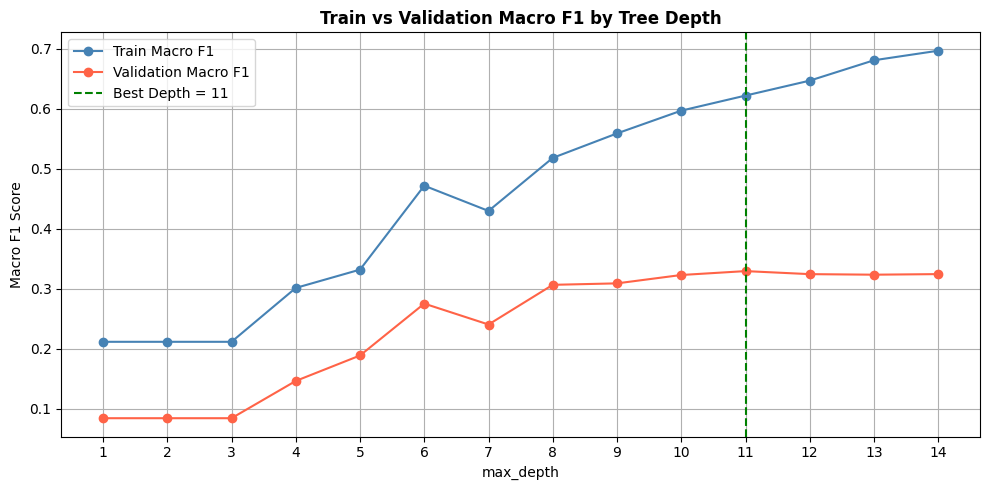

In [ ]:
# Testing different depths to find best fit
from sklearn.metrics import f1_score

train_scores = []
val_scores   = []
depths = range(1, 15)

for depth in depths:
    m = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=20,
        min_samples_split=20,
        class_weight=class_weight_dict,
        random_state=42
    )
    m.fit(X_train_bal, y_train_bal)
    train_scores.append(f1_score(y_train_bal, m.predict(X_train_bal), average='macro'))
    val_scores.append(f1_score(y_val,         m.predict(X_val),       average='macro'))

best_depth = list(depths)[val_scores.index(max(val_scores))]
print("Best max_depth (by macro F1):", best_depth)
print("Best Validation Macro F1    :", round(max(val_scores), 4))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, label='Train Macro F1',      marker='o', color='steelblue')
plt.plot(depths, val_scores,   label='Validation Macro F1', marker='o', color='tomato')
plt.axvline(x=best_depth, color='green', linestyle='--', label=f'Best Depth = {best_depth}')
plt.title('Train vs Validation Macro F1 by Tree Depth', fontweight='bold')
plt.xlabel('max_depth')
plt.ylabel('Macro F1 Score')
plt.legend()
plt.xticks(list(depths))
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
clf = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=20,
    min_samples_split=20,
    class_weight=class_weight_dict,
    random_state=42
)
clf.fit(X_train_bal, y_train_bal)
print("Final model trained with max_depth =", best_depth)
print("Classes:", clf.classes_)

Final model trained with max_depth = 11
Classes: ['canceled' 'checkout' 'no-show']


Evaluate on Validation Set

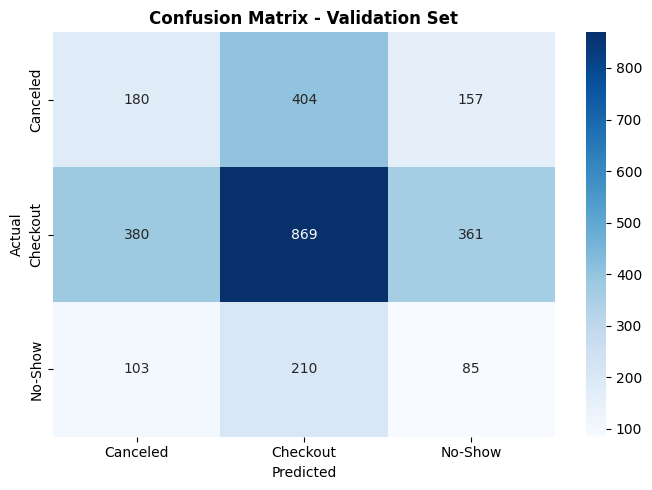

In [ ]:
classes = ['canceled', 'checkout', 'no-show']
y_pred_val = clf.predict(X_val)

cm_val = confusion_matrix(y_val, y_pred_val, labels=classes)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Canceled', 'Checkout', 'No-Show'],
            yticklabels=['Canceled', 'Checkout', 'No-Show'])
plt.title('Confusion Matrix - Validation Set', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
print("=== Classification Report (Validation) ===")
print(classification_report(y_val, y_pred_val,
      target_names=['Canceled', 'Checkout', 'No-Show']))

=== Classification Report (Validation) ===
              precision    recall  f1-score   support

    Canceled       0.27      0.24      0.26       741
    Checkout       0.59      0.54      0.56      1610
     No-Show       0.14      0.21      0.17       398

    accuracy                           0.41      2749
   macro avg       0.33      0.33      0.33      2749
weighted avg       0.44      0.41      0.42      2749



Train vs Validation Accuracy Summary

In [ ]:
from sklearn.metrics import f1_score, accuracy_score

train_acc   = accuracy_score(y_train_bal, clf.predict(X_train_bal))
val_acc     = accuracy_score(y_val, y_pred_val)
train_macro = f1_score(y_train_bal, clf.predict(X_train_bal), average='macro')
val_macro   = f1_score(y_val, y_pred_val, average='macro')

print("Train Accuracy      :", round(train_acc   * 100, 2), "%")
print("Validation Accuracy :", round(val_acc     * 100, 2), "%")
print("Train Macro F1      :", round(train_macro, 4))
print("Validation Macro F1 :", round(val_macro,   4))
print("Accuracy Difference :", round((train_acc - val_acc) * 100, 2), "%")

if (train_acc - val_acc) < 0.05:
    print("Good fit")
elif (train_acc - val_acc) < 0.10:
    print("Slight overfitting")
else:
    print("Overfitting")

Train Accuracy      : 63.25 %
Validation Accuracy : 41.25 %
Train Macro F1      : 0.6223
Validation Macro F1 : 0.3294
Accuracy Difference : 22.0 %
Overfitting


ROC-AUC + ROC Curves

ROC-AUC Score (Validation, macro): 0.4993


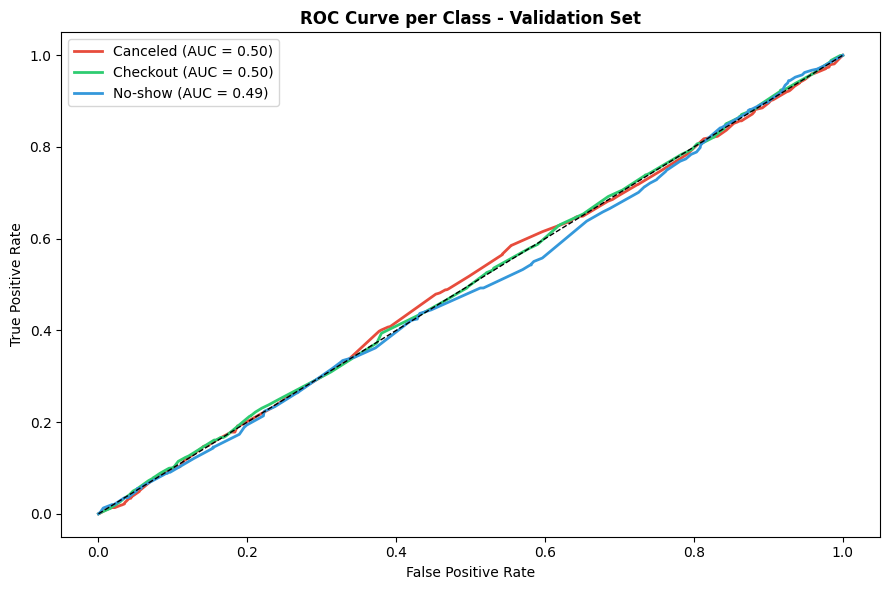

In [ ]:
from sklearn.metrics import roc_curve, auc

y_val_bin      = label_binarize(y_val, classes=classes)
y_pred_proba   = clf.predict_proba(X_val)

roc_auc_macro = roc_auc_score(y_val_bin, y_pred_proba,
                               average='macro', multi_class='ovr')
print("ROC-AUC Score (Validation, macro):", round(roc_auc_macro, 4))

# Plot ROC curve per class
colors = ['#e74c3c', '#2ecc71', '#3498db']
plt.figure(figsize=(9, 6))
for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_pred_proba[:, i])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cls.capitalize()} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title('ROC Curve per Class - Validation Set', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

ROC-AUC Score (Validation)

In [ ]:
classes = ['canceled', 'checkout', 'no-show']

y_val_bin = label_binarize(y_val, classes=classes)
y_pred_proba_val = clf.predict_proba(X_val)

roc_auc = roc_auc_score(y_val_bin, y_pred_proba_val,
                        average='macro', multi_class='ovr')
print("ROC-AUC Score (Validation):", round(roc_auc, 4))

ROC-AUC Score (Validation): 0.4993


Feature importance

/tmp/ipykernel_4348/3003192963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


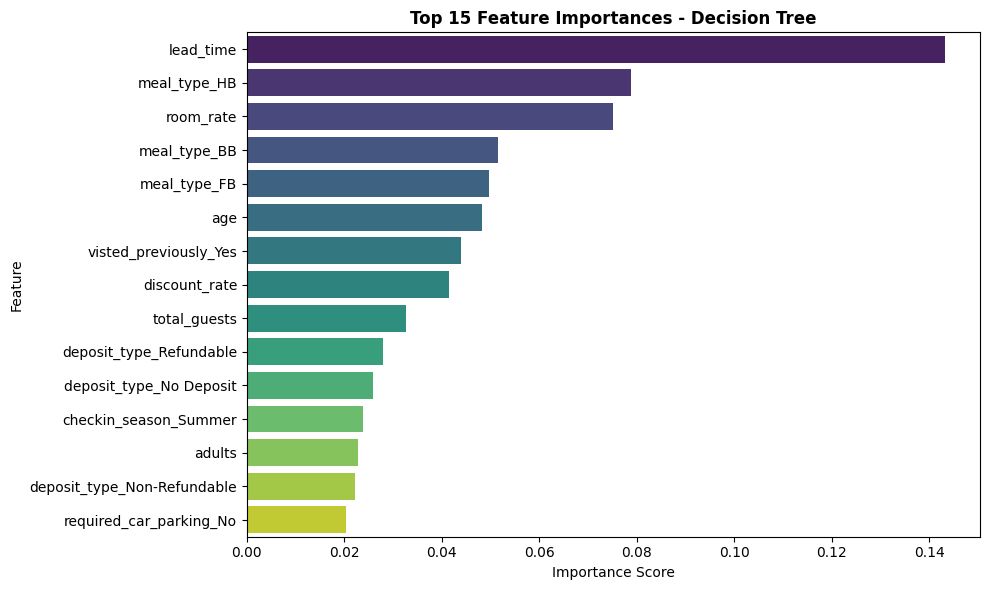

                    Feature  Importance
                  lead_time    0.143211
               meal_type_HB    0.078759
                  room_rate    0.075054
               meal_type_BB    0.051517
               meal_type_FB    0.049640
                        age    0.048262
      visted_previously_Yes    0.043982
              discount_rate    0.041523
               total_guests    0.032694
    deposit_type_Refundable    0.028006
    deposit_type_No Deposit    0.025775
      checkin_season_Summer    0.023859
                     adults    0.022803
deposit_type_Non-Refundable    0.022201
    required_car_parking_No    0.020240


In [ ]:
importance_df = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': clf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances - Decision Tree', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

Visualise the Tree

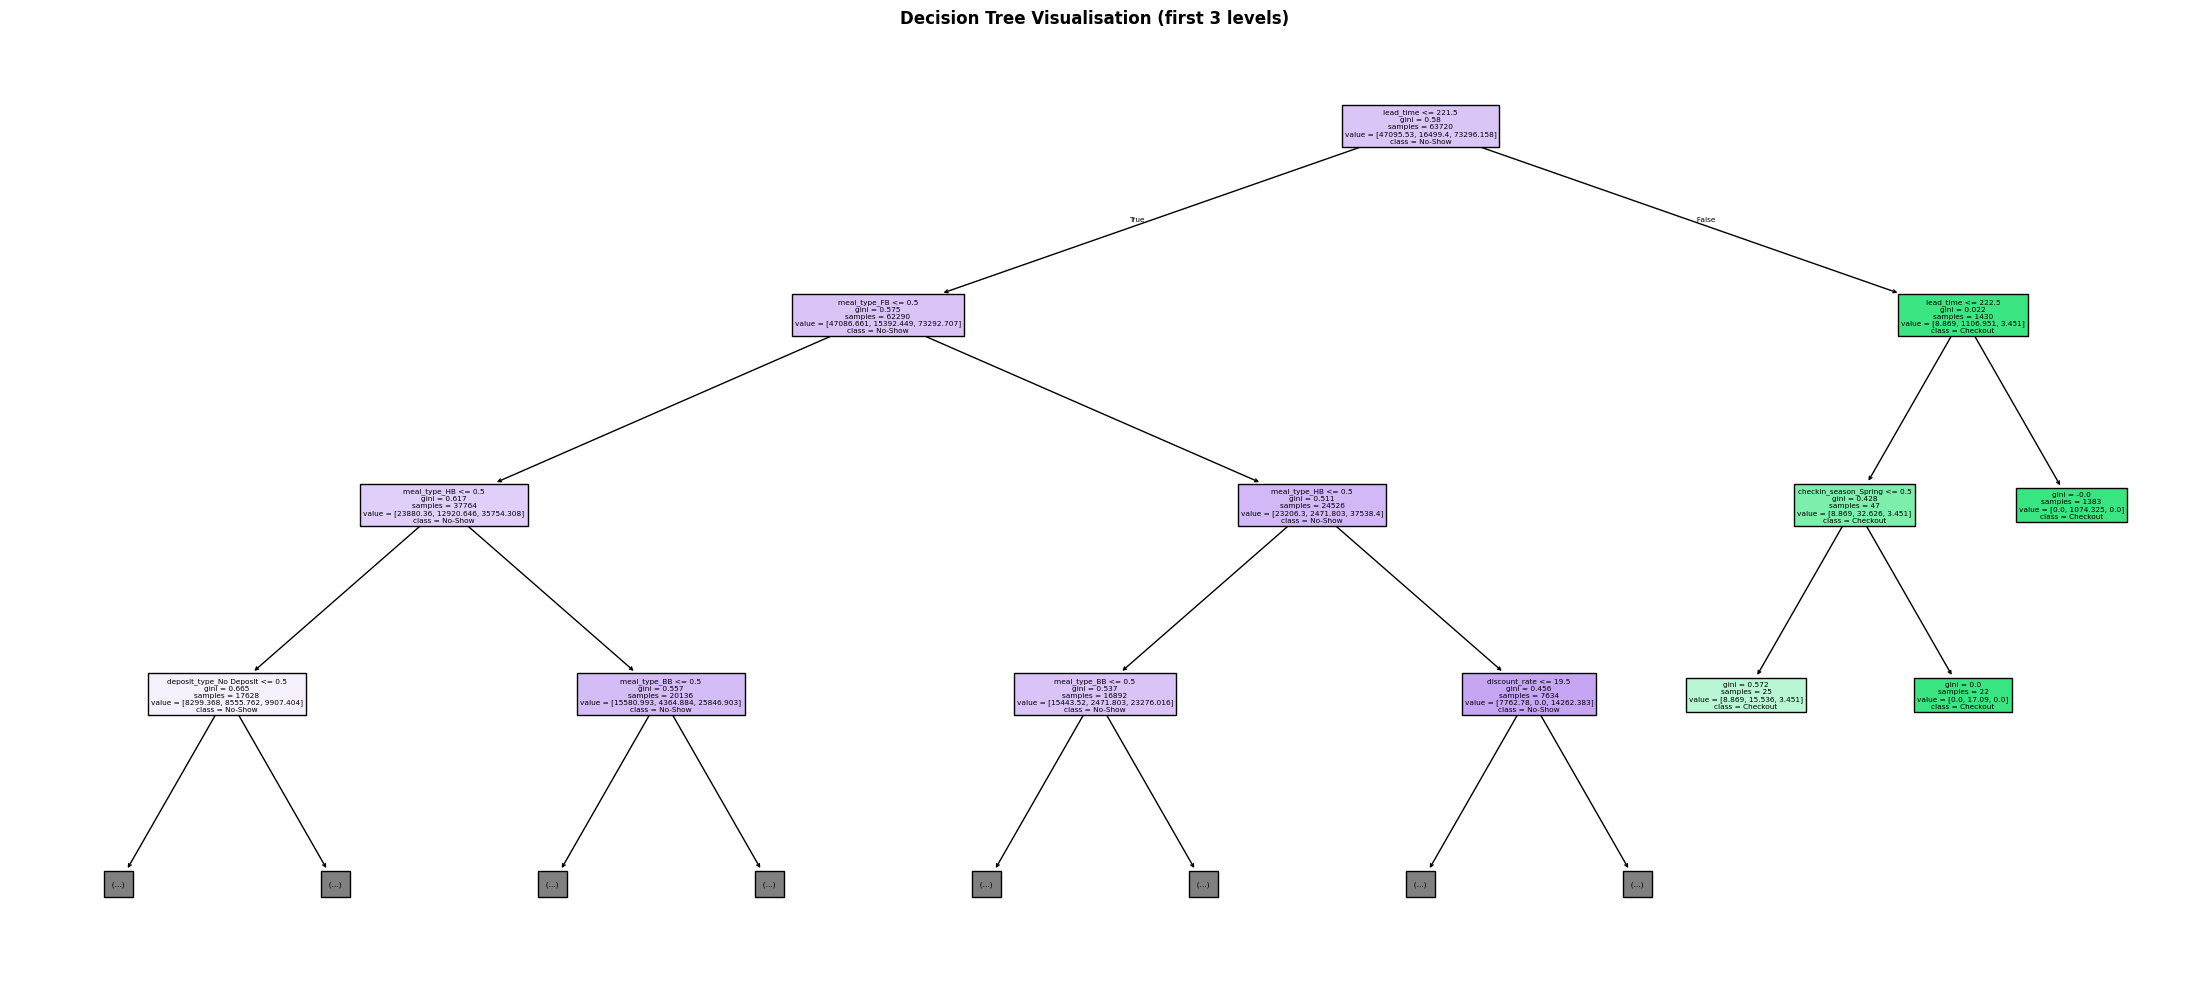

In [ ]:
plt.figure(figsize=(22, 10))
plot_tree(clf,
          feature_names=X_train.columns,
          class_names=['Canceled', 'Checkout', 'No-Show'],
          filled=True, max_depth=3)
plt.title('Decision Tree Visualisation (first 3 levels)', fontweight='bold')
plt.tight_layout()
plt.show()

## Predict on the Test Set

Generating predictions and cancellation probabilities for the final test dataset.

In [ ]:
# Generate predictions for test set
test_predictions = clf.predict(X_test)
test_proba       = clf.predict_proba(X_test)

test['predicted_status']    = test_predictions
test[['prob_canceled', 'prob_checkout', 'prob_noshow']] = test_proba

print("Test Predictions Distribution:")
print(pd.Series(test_predictions).value_counts())
print()
print(test[['predicted_status', 'prob_canceled', 'prob_checkout', 'prob_noshow']].head(10))

Test Predictions Distribution:
checkout    2324
canceled    1042
no-show      952
Name: count, dtype: int64

  predicted_status  prob_canceled  prob_checkout  prob_noshow
0         checkout       0.254814       0.410416     0.334770
1         canceled       0.385805       0.286149     0.328045
2         checkout       0.235682       0.427631     0.336688
3         canceled       0.460068       0.133181     0.406751
4         checkout       0.033712       0.948798     0.017489
5          no-show       0.259420       0.309696     0.430885
6         checkout       0.383957       0.419475     0.196567
7         canceled       0.515377       0.096855     0.387768
8         canceled       0.405619       0.278743     0.315638
9         canceled       0.621423       0.192589     0.185988


## Save Test Predictions to CSV

In [ ]:
from pathlib import Path

output_path = '/content/drive/MyDrive/DSPL/GCW/Data/Outputs/decision_tree_test_predictions.csv'
test.to_csv(output_path, index=False)
print(f'Predictions saved to: {output_path}')

Predictions saved to: /content/drive/MyDrive/DSPL/GCW/Data/Outputs/decision_tree_test_predictions.csv
